# Chento partial take-profits 2026-09

Pre-registration: [README.md](README.md), frozen in `results/freeze_F0.json` before any ladder outcome. Write-up:
[findings.md](findings.md). Chento's own trim arithmetic (fractions of the running position at fixed R-levels)
on the exit-policy study's 392 entries, against the shipped single 6R target, with a random-level placebo.
Re-run: `partial_run.py freeze0`, then `partial_run.py outcomes`.


## Freeze and gates — A0 reproduced against the committed exit-policy record

In [1]:
import json, pandas as pd
from pathlib import Path
R = Path('results')
F0 = json.loads((R / 'freeze_F0.json').read_text(encoding='utf-8'))
J = json.loads((R / 'report.json').read_text(encoding='utf-8'))
V = json.loads((R / 'verdict.json').read_text(encoding='utf-8'))
print('freeze F0:', F0['created_utc'], '| outcomes started:', J['started_utc'])
print('gates:', json.dumps(J['gates'], indent=1))
print('A0 exit kinds:', J['a0_exit_kinds'])


freeze F0: 2026-09-18T22:19:36+00:00 | outcomes started: 2026-09-18T22:19:37+00:00
gates: {
 "G1": {
  "reference": "studies\\notebooks\\exit_policy_2026_09\\results\\chento\\walks.csv.gz",
  "reference_sha256": "9e6d4255e46315e814462b3cd266fe341208bb3adf5874e197e2edd2ecfce64f",
  "trades": 392,
  "matched": 392,
  "max_abs_diff_net_R": 4.440892098500626e-16,
  "pass_": true
 },
 "G2": {
  "max_abs_diff": 0.0,
  "pass_": true
 }
}
A0 exit kinds: {'stop': 194, 'time': 159, 'target': 39}


## Sequences — mean R, cumulative R, drawdown, MAR by arm and scope

In [2]:
rows = []
for arm, s in J['sequences'].items():
    for scope in ('pooled', 'BTC', 'ETH', 'first_half', 'second_half'):
        x = s[scope]; rows.append(dict(arm=arm, scope=scope, trades=x['trades'], mean_net_R=x['mean_net_R'],
                                       cum_R=x['cum_R'], win_rate=x['win_rate'], max_dd_R=x['max_dd_R'], MAR_R=x['MAR_R']))
df = pd.DataFrame(rows)
for scope in ('pooled', 'BTC', 'ETH', 'first_half', 'second_half'):
    print(scope); display(df[df.scope == scope].set_index('arm').drop(columns='scope').round(3))


pooled


,trades,mean_net_R,cum_R,win_rate,max_dd_R,MAR_R
arm,,,,,,
A0,392,0.634,248.339,0.421,-18.273,2.542
P1,392,0.435,170.542,0.464,-15.241,2.093
P2,392,0.517,202.727,0.436,-17.940,2.113
P3,392,0.398,156.117,0.469,-15.254,1.914


BTC


,trades,mean_net_R,cum_R,win_rate,max_dd_R,MAR_R
arm,,,,,,
A0,208,0.725,150.782,0.452,-14.128,1.996
P1,208,0.508,105.633,0.510,-10.575,1.868
P2,208,0.590,122.824,0.471,-13.659,1.682
P3,208,0.474,98.695,0.519,-10.048,1.837


ETH


,trades,mean_net_R,cum_R,win_rate,max_dd_R,MAR_R
arm,,,,,,
A0,184,0.530,97.556,0.386,-12.829,1.505
P1,184,0.353,64.910,0.413,-9.907,1.296
P2,184,0.434,79.904,0.397,-12.829,1.232
P3,184,0.312,57.422,0.413,-8.799,1.291


first_half


,trades,mean_net_R,cum_R,win_rate,max_dd_R,MAR_R
arm,,,,,,
A0,181,1.044,189.030,0.503,-9.678,7.432
P1,181,0.707,128.044,0.530,-7.527,6.472
P2,181,0.857,155.075,0.519,-8.679,6.798
P3,181,0.632,114.472,0.525,-7.552,5.767


second_half


,trades,mean_net_R,cum_R,win_rate,max_dd_R,MAR_R
arm,,,,,,
A0,211,0.281,59.309,0.351,-18.273,1.240
P1,211,0.201,42.498,0.408,-15.241,1.065
P2,211,0.226,47.652,0.365,-17.940,1.015
P3,211,0.197,41.645,0.422,-15.254,1.043


## Paired differences, fills and the placebo

In [3]:
print('paired vs A0 (net R per trade):')
display(pd.DataFrame(J['paired_vs_A0']).T.round(3))
print('fills:')
display(pd.DataFrame(J['fills']).T)
print('placebo (same fractions, random levels):')
display(pd.DataFrame(J['placebo']).T)


paired vs A0 (net R per trade):


,mean_d,ci95,mean_d_BTC,mean_d_ETH,mean_d_first_half,mean_d_second_half,trades_changed
P1,-0.19846,"[-0.329414660962034, -0.19508175784664822, -0....",-0.217066,-0.177428,-0.336938,-0.079671,228
P2,-0.116355,"[-0.20041001138539202, -0.11433575703542695, -...",-0.134417,-0.095938,-0.187597,-0.055242,101
P3,-0.235259,"[-0.3895074264607219, -0.23098268941453426, -0...",-0.250421,-0.21812,-0.411923,-0.083713,228


fills:


,share_with_any_fill,share_filled_by_level,mean_closed_early,median_hours_to_first_fill,trades
P1,0.581633,"{'1.0': 0.5816326530612245, '2.0': 0.372448979...",0.237398,11.125,392
P2,0.257653,{'3.0': 0.2576530612244898},0.128827,28.25,392
P3,0.581633,{'1.0': 0.5816326530612245},0.290816,11.125,392


placebo (same fractions, random levels):


,draws,fractions,level_range,seed,MAR_R_p05,MAR_R_p50,MAR_R_p95,mean_net_R_p50,candidate_percentile
P1,500,"[0.25, 0.2, 0.1, 0.2]","[0.5, 5.5]",7,1.907433,2.148243,2.305817,0.460656,0.354
P2,500,[0.5],"[0.5, 5.5]",7,1.891751,2.24586,2.427369,0.522558,0.296
P3,500,[0.5],"[0.5, 5.5]",7,1.891751,2.24586,2.427369,0.522558,0.066


## Cumulative net R by arm

Text(0, 0.5, 'R')

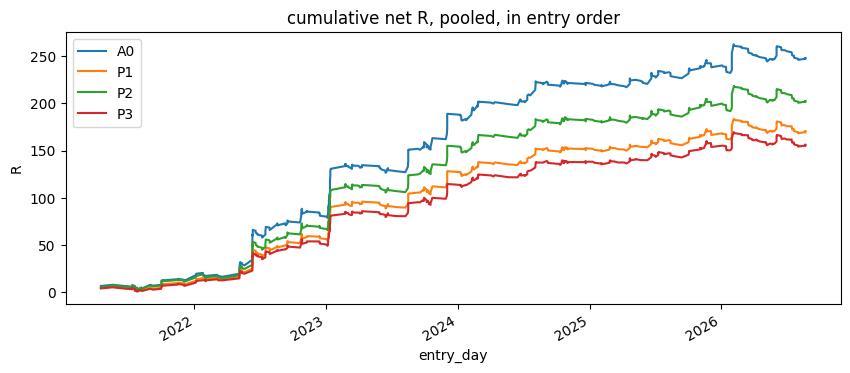

In [4]:
pt = pd.read_csv(R / 'per_trade.csv.gz')
pt['entry_day'] = pd.to_datetime(pt['entry_day'])
pt = pt.sort_values(['entry_day', 't'])
cum = pt.set_index('entry_day')[[c for c in pt.columns if c.startswith('net_R_')]].cumsum()
cum.columns = [c.replace('net_R_', '') for c in cum.columns]
ax = cum.plot(figsize=(10, 4), title='cumulative net R, pooled, in entry order')
ax.set_ylabel('R')


## Decision (rule fixed in README.md §6 before the run)

In [5]:
print('VERDICT:', V['verdict'])
print(json.dumps(V['clauses'], indent=1))


VERDICT: KEEP_6R
{
 "P1": {
  "D1_mar_gain_both_assets": false,
  "D2_mar_both_halves": false,
  "D3_bounded_cost": false,
  "passes": false,
  "placebo_p95_MAR_R": 2.3058168806531882,
  "levels_beat_placebo_p95": false
 },
 "P2": {
  "D1_mar_gain_both_assets": false,
  "D2_mar_both_halves": false,
  "D3_bounded_cost": false,
  "passes": false,
  "placebo_p95_MAR_R": 2.4273688528505457,
  "levels_beat_placebo_p95": false
 },
 "P3": {
  "D1_mar_gain_both_assets": false,
  "D2_mar_both_halves": false,
  "D3_bounded_cost": false,
  "passes": false,
  "placebo_p95_MAR_R": 2.4273688528505457,
  "levels_beat_placebo_p95": false
 }
}
